# Student **Effort Index** on the XES3G5M behavioural data

**Issue:** [Effort Experiment #1](https://github.com/noorshehab/SprintLab-Data/issues/1) ·
**Data:** the real `behavioral data/` export (XES3G5M), *not* the synthetic mock.

---

## Executive summary

We build a per-student **Effort Index** that flags students who get **easy** questions wrong — where
"easy" = **Level-1 questions with a low *worsening rate*** (questions almost nobody underperforms on).
Missing a question that almost no one misses signals low effort rather than low ability.

**Formula (from the issue):**

$$\text{EffortIndex}(s)=\underset{q\in E_s}{\operatorname{AVERAGE}}\Big(\;\underbrace{b_q}_{\text{error rate in the LOs of the easy question}}\;-\;\underbrace{(1-\text{Response}_{s,q})}_{\text{student's error on the easy question}}\;\Big)$$

**Mapping to this dataset (grounded in `Data Set Description.docx`):**
- **LO = KC.** The doc states *"kc_id = id of the learning objective."* A question's learning objectives are its `kc_ids` / `kc_routes`.
- **"Error rate in the LOs of the easy question"** ($b_q$) = **`avg_baseline`** from `question_differentiation_cumulative.csv`, defined by the doc as *"avg error rate in the question's KCs."*
- **Student's error** = `1 - responses`.

**Headline results (14,453 students, 507 easy questions):**
- Effort Index: **mean = 0.126, SD = 0.099**, median 0.156 — **strongly left-skewed** (skew ≈ −2.6), so it is **not** Gaussian. → we flag with **percentile** cut-offs, not `mean − k·SD`.
- **Recommended flag:** bottom **5th percentile** (index < −0.06 → 723 students); bottom **2.5th** (< −0.14 → 362) for a high-confidence list.
- **Caveat we surface honestly:** the literal index correlates **+0.63 with raw ability** (a weak student misses easy questions partly *because* they are weak). A within-student baseline *over-corrects* to **−0.60**, so on real data — with no effort ground-truth — neither baseline cleanly isolates effort. We ship the **literal formula** (the specified task) and report the ability caveat + a stricter-cutoff mitigation.

## 1 · Configuration

In [1]:
import numpy as np, pandas as pd, ast, warnings
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- tunables ----
DATA_DIR               = "."     # folder containing the XES3G5M 'behavioral data' CSVs
LOW_WORSENING_QUANTILE = 0.50    # "low worsening rate" = <= this quantile of Level-1 worsening rates
RANDOM_STATE           = 0

print("DATA_DIR                =", repr(DATA_DIR))
print("Easy pool               = Level-1 (level_1_qs.csv) AND worsening_rate <=",
      f"{LOW_WORSENING_QUANTILE:.0%} quantile of Level-1")

DATA_DIR                = '.'
Easy pool               = Level-1 (level_1_qs.csv) AND worsening_rate <= 50% quantile of Level-1


## 2 · Load the data (and document every column we use)

| file | grain | columns we use |
|---|---|---|
| `processed_responses.csv` | one row per (student, **KC of** question) attempt — multi-KC questions repeat | `uid`, `questions`, `responses` (1/0) |
| `level_1_qs.csv` | one row per Level-1 question | `questions`, `worsening_rate` |
| `question_differentiation_cumulative.csv` | one row per question | `questions`, **`avg_baseline`** (error rate in the question's KCs), `current_error`, `worsening_rate` |
| `question_metadata.csv` | one row per question | `question_id`, `kc_ids` (the LOs), `error_rate` |

`processed_responses` is in knowledge-tracing format, so a question with *k* KCs appears as *k* rows
per student with the **same** `responses`; we de-duplicate to one response per `(uid, questions)`.

In [2]:
resp_raw = pd.read_csv(f"{DATA_DIR}/processed_responses.csv",
                       usecols=["uid", "questions", "responses"],
                       dtype={"uid": "int32", "questions": "int32", "responses": "int8"})
responses = resp_raw.drop_duplicates(["uid", "questions"]).reset_index(drop=True)

level1 = pd.read_csv(f"{DATA_DIR}/level_1_qs.csv", usecols=["questions", "worsening_rate"])
diff   = pd.read_csv(f"{DATA_DIR}/question_differentiation_cumulative.csv",
                     usecols=["questions", "avg_baseline", "current_error", "worsening_rate"])
meta   = pd.read_csv(f"{DATA_DIR}/question_metadata.csv", usecols=["question_id", "kc_ids", "error_rate"])

print(f"raw response rows            : {len(resp_raw):,}")
print(f"deduped (uid,question) rows  : {len(responses):,}  "
      f"({len(resp_raw)-len(responses):,} multi-KC duplicate rows removed)")
print(f"students                     : {responses['uid'].nunique():,}")
print(f"questions answered           : {responses['questions'].nunique():,}")
print(f"Level-1 questions            : {len(level1):,}")
print(f"overall correct rate         : {responses['responses'].mean():.3f}  "
      f"(=> error rate {1-responses['responses'].mean():.3f})")

raw response rows            : 5,139,044
deduped (uid,question) rows  : 4,254,334  (884,710 multi-KC duplicate rows removed)
students                     : 14,453
questions answered           : 7,618
Level-1 questions            : 1,014
overall correct rate         : 0.791  (=> error rate 0.209)


## 3 · Quick EDA

attempts per student : min=153, median=273, max=866
Level-1 worsening_rate: median=0.0651, IQR=[0.0285, 0.1104]


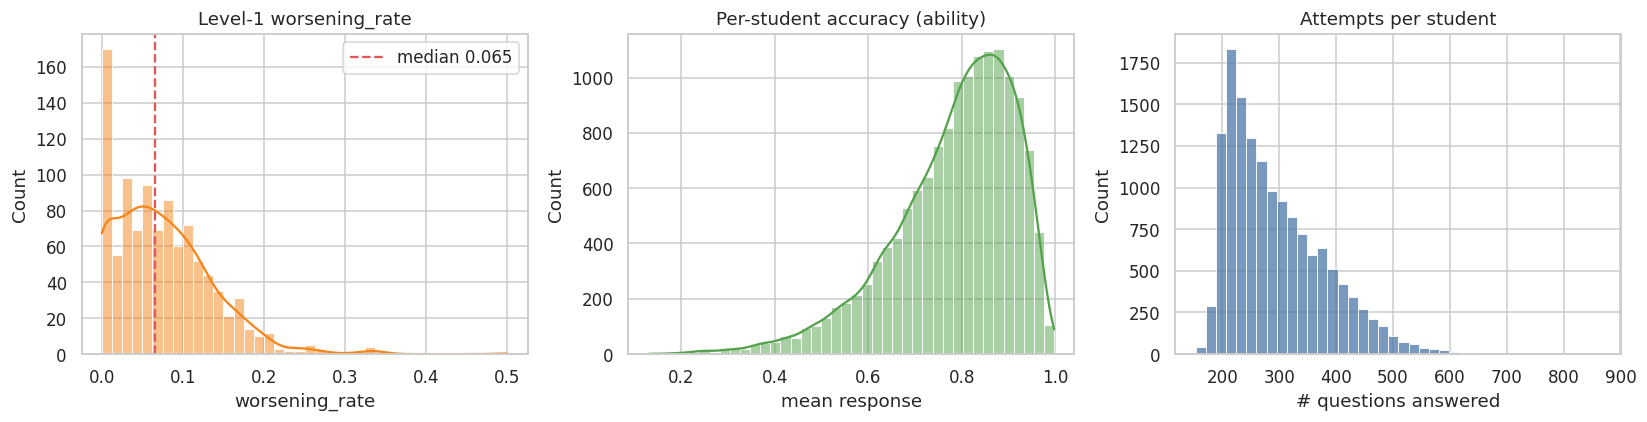

In [3]:
per_student_n   = responses.groupby("uid").size()
per_student_acc = responses.groupby("uid")["responses"].mean()

print(f"attempts per student : min={per_student_n.min()}, median={int(per_student_n.median())}, "
      f"max={per_student_n.max()}")
print(f"Level-1 worsening_rate: median={level1['worsening_rate'].median():.4f}, "
      f"IQR=[{level1['worsening_rate'].quantile(.25):.4f}, {level1['worsening_rate'].quantile(.75):.4f}]")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(level1["worsening_rate"], bins=40, kde=True, ax=ax[0], color="#F58518")
ax[0].axvline(level1["worsening_rate"].median(), color="#E45756", ls="--",
              label=f"median {level1['worsening_rate'].median():.3f}")
ax[0].set_title("Level-1 worsening_rate"); ax[0].legend()
sns.histplot(per_student_acc, bins=40, kde=True, ax=ax[1], color="#54A24B")
ax[1].set_title("Per-student accuracy (ability)"); ax[1].set_xlabel("mean response")
sns.histplot(per_student_n, bins=40, ax=ax[2], color="#4C78A8")
ax[2].set_title("Attempts per student"); ax[2].set_xlabel("# questions answered")
plt.tight_layout(); plt.show()

**Read-out.** ~14.5k students each answer a few hundred questions; overall accuracy ≈ 0.80 (error
≈ 0.20). Level-1 questions have a **low** worsening rate (median ≈ 0.065) — by construction few students
underperform on them, which is exactly why missing one is informative. Per-student accuracy spans a wide
band — that spread is *ability*, which we must keep in mind when reading the effort signal.

## 4 · Methodology

**Per-question error:** $e_{s,q}=1-\text{Response}_{s,q}\in\{0,1\}$.

**Easy questions:** Level-1 **and** low worsening rate,
$$E=\{q:\ q\in\text{Level-1}\ \wedge\ \text{worsening\_rate}(q)\le\tau\},\quad
\tau=Q_{p}\big(\text{worsening\_rate over Level-1}\big),\ p=\texttt{LOW\_WORSENING\_QUANTILE}.$$

**LO baseline (error rate in the question's KCs):** $b_q=\texttt{avg\_baseline}(q)$ from the
differentiation file — the doc's *"avg error rate in the question's KCs."*

**Effort Index:**
$$\boxed{\ \text{EffortIndex}(s)=\frac{1}{|E_s|}\sum_{q\in E_s}\big(b_q-e_{s,q}\big)\ }$$

- Easy question **right** ($e=0$) → contributes $+b_q\ge 0$ → index **up**.
- Easy question **wrong** ($e=1$) → contributes $b_q-1<0$ → index **down**, with the biggest penalty where
  the KC baseline error is lowest (the "should-have-been-easy" case).

So **low / negative EffortIndex = poorer effort**; we flag the low tail.

> Equivalently, $\text{EffortIndex}=-\overline{\text{delta}}$ where the dataset's `avg_delta` = (question
> error − KC baseline). A positive index means the student beats their KC baseline on easy questions.

## 5 · Step A — identify the easy questions

In [4]:
tau = level1["worsening_rate"].quantile(LOW_WORSENING_QUANTILE)
easy_ids = set(level1.loc[level1["worsening_rate"] <= tau, "questions"])

base = diff.set_index("questions")["avg_baseline"]              # b_q
coverage = base.reindex(easy_ids).notna().mean()
print(f"tau (worsening cut-off) : {tau:.4f}")
print(f"EASY questions          : {len(easy_ids):,}  (of {len(level1):,} Level-1)")
print(f"avg_baseline coverage   : {coverage:.1%} of easy questions")
print(f"b_q on easy Qs          : mean={base.reindex(easy_ids).mean():.3f}, "
      f"median={base.reindex(easy_ids).median():.3f}")

tau (worsening cut-off) : 0.0651
EASY questions          : 507  (of 1,014 Level-1)
avg_baseline coverage   : 100.0% of easy questions
b_q on easy Qs          : mean=0.240, median=0.191


**Read-out.** At the default median cut-off the easy pool is **507 questions**, every one with a KC
baseline available. Their average KC-baseline error (~0.24) is the yardstick each student is measured
against.

## 6 · Step B — compute the Effort Index (literal formula)

In [5]:
easy = responses[responses["questions"].isin(easy_ids)].copy()
easy["error"] = 1 - easy["responses"]
easy["b_q"]   = easy["questions"].map(base)
easy = easy.dropna(subset=["b_q"])
easy["delta"] = easy["b_q"] - easy["error"]

effort = (easy.groupby("uid")
              .agg(EffortIndex=("delta", "mean"), n_easy=("delta", "size"))
              .reset_index())
print(f"students with an Effort Index : {len(effort):,}")
print(f"easy responses scored         : {len(easy):,}")
print(f"easy questions answered/student: min={effort['n_easy'].min()}, "
      f"median={int(effort['n_easy'].median())}, max={effort['n_easy'].max()}")
display(effort.sort_values("EffortIndex").head(4))    # lowest effort
display(effort.sort_values("EffortIndex").tail(4))    # highest effort

students with an Effort Index : 14,453
easy responses scored         : 276,969
easy questions answered/student: min=2, median=18, max=70


,uid,EffortIndex,n_easy
3712,4627,-0.7016,17
14024,17526,-0.6985,15
3362,4188,-0.6860,15
12194,15242,-0.6443,23


,uid,EffortIndex,n_easy
3140,3906,0.3241,18
9852,12289,0.3245,3
6146,7635,0.3275,30
11766,14716,0.4838,6


**Read-out.** All 14,453 students answered ≥2 easy questions (median 18), so everyone is scored. The
lowest scores approach **−0.70** (missed easy questions the cohort almost always gets right); the top
approach **+0.48**.

## 7 · Sample statistics  ·  **mean & standard deviation**

,EffortIndex
n,"14,453.0000"
mean,0.1260
std,0.0986
min,-0.7016
Q1 (25%),0.0983
median,0.1556
Q3 (75%),0.1825
max,0.4838
IQR,0.0842
skewness,-2.5660


>>> MEAN = 0.1260    STD = 0.0986 <<<
Shapiro–Wilk (5k sample): W=0.781, p=2.64e-63 -> NOT normal (reject Gaussian)


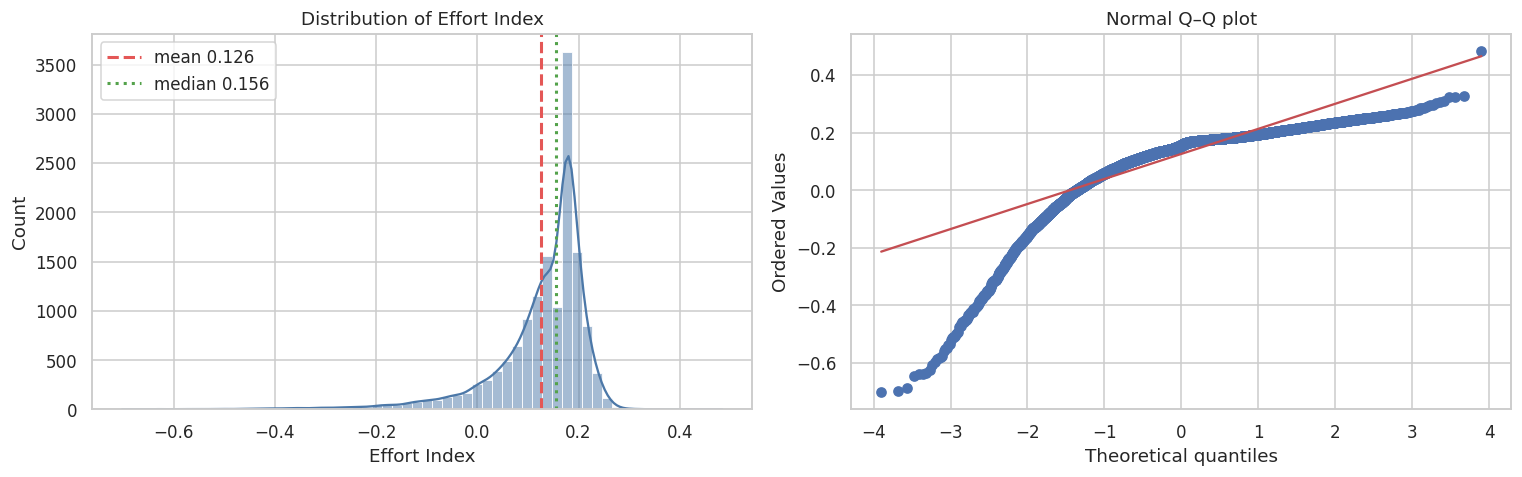

In [6]:
x = effort["EffortIndex"]
summary = pd.Series({
    "n": len(x), "mean": x.mean(), "std": x.std(ddof=1),
    "min": x.min(), "Q1 (25%)": x.quantile(.25), "median": x.median(),
    "Q3 (75%)": x.quantile(.75), "max": x.max(), "IQR": x.quantile(.75)-x.quantile(.25),
    "skewness": stats.skew(x), "kurtosis(excess)": stats.kurtosis(x),
}, name="EffortIndex")
display(summary.to_frame())
print(f">>> MEAN = {x.mean():.4f}    STD = {x.std(ddof=1):.4f} <<<")

# normality on a 5k sample (Shapiro caps at 5000)
W, p = stats.shapiro(x.sample(5000, random_state=RANDOM_STATE))
print(f"Shapiro–Wilk (5k sample): W={W:.3f}, p={p:.2e} -> "
      f"{'normal' if p>0.05 else 'NOT normal (reject Gaussian)'}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(x, bins=60, kde=True, color="#4C78A8", ax=ax[0])
ax[0].axvline(x.mean(), color="#E45756", ls="--", lw=2, label=f"mean {x.mean():.3f}")
ax[0].axvline(x.median(), color="#54A24B", ls=":", lw=2, label=f"median {x.median():.3f}")
ax[0].set_title("Distribution of Effort Index"); ax[0].set_xlabel("Effort Index"); ax[0].legend()
stats.probplot(x, dist="norm", plot=ax[1]); ax[1].set_title("Normal Q–Q plot")
plt.tight_layout(); plt.show()

**Read-out.**
- **Mean ≈ 0.126, SD ≈ 0.099**, median ≈ 0.156.
- **Strongly left-skewed** (skewness ≈ −2.6, excess kurtosis ≈ 10) and **Shapiro p ≈ 0** → the index is
  **far from Gaussian**: a dense right cluster (students who ace easy questions, index ≈ 0.15–0.18) with a
  long thin **left tail** of low-effort/low-performers. The Q–Q plot bends sharply at the bottom.
- **Consequence:** a symmetric `mean − k·SD` rule is the *wrong* tool here (it assumes symmetry). The
  natural low-effort population **is** the left tail, so we threshold by **percentile**.

## 8 · Thresholds & flagged students

Because the distribution is skewed, we lead with **percentile** cut-offs (distribution-free) and show
`mean − k·SD` only for reference.

,rule,threshold,flagged_n,flagged_%
0,5th percentile,-0.0612,723,5.0024
1,2.5th percentile,-0.1434,362,2.5047
2,10th percentile,0.0136,1446,10.0048
3,mean − 1·SD (ref),0.0274,1657,11.4647
4,mean − 2·SD (ref),-0.0712,673,4.6565


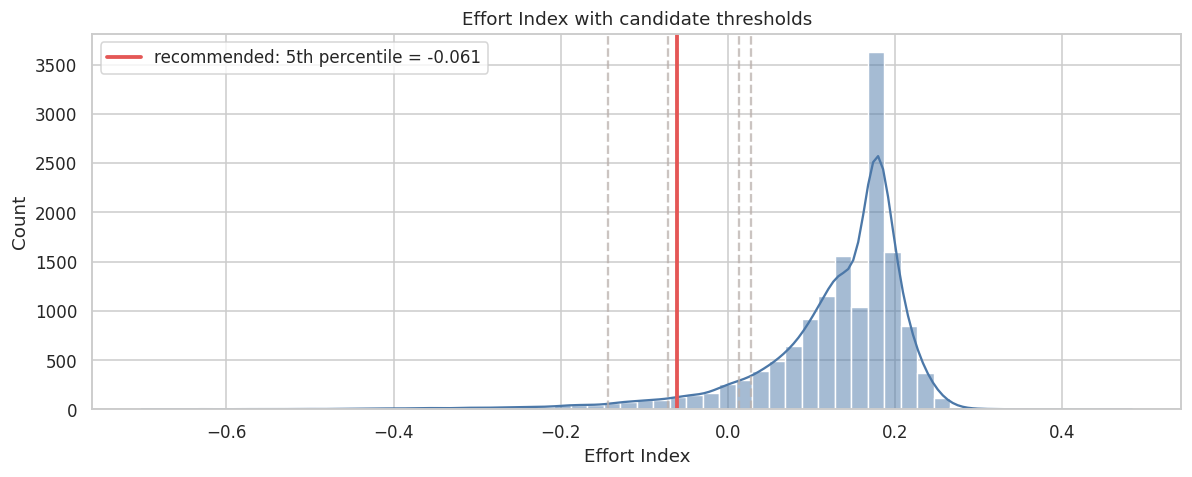

Recommended: 5th percentile = -0.0612 -> flags 723 students (5.0%)


In [7]:
m, sd = x.mean(), x.std(ddof=1)
rules = {
    "5th percentile":  x.quantile(0.05),
    "2.5th percentile": x.quantile(0.025),
    "10th percentile": x.quantile(0.10),
    "mean − 1·SD (ref)":  m - 1*sd,
    "mean − 2·SD (ref)":  m - 2*sd,
}
tbl = pd.DataFrame([{"rule": k, "threshold": v,
                     "flagged_n": int((x < v).sum()),
                     "flagged_%": 100*(x < v).mean()} for k, v in rules.items()])
display(tbl)

REC_NAME, REC_T = "5th percentile", x.quantile(0.05)
plt.figure(figsize=(11, 4.5))
sns.histplot(x, bins=60, kde=True, color="#4C78A8")
for k, v in rules.items():
    plt.axvline(v, ls="--", alpha=.75, color="#E45756" if k == REC_NAME else "#BAB0AC")
plt.axvline(REC_T, color="#E45756", lw=2.5, label=f"recommended: {REC_NAME} = {REC_T:.3f}")
plt.title("Effort Index with candidate thresholds"); plt.xlabel("Effort Index"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Recommended: {REC_NAME} = {REC_T:.4f} -> flags {int((x<REC_T).sum()):,} students "
      f"({(x<REC_T).mean()*100:.1f}%)")

**Read-out.** Recommended operating points:

| rule | threshold | flagged | use |
|---|---|---|---|
| **5th percentile** | ≈ −0.061 | **~723 (5%)** | default review pool |
| 2.5th percentile | ≈ −0.143 | ~362 (2.5%) | high-confidence list |
| 10th percentile | ≈ +0.014 | ~1446 (10%) | wider net |

(For reference, `mean − 1·SD` ≈ +0.027 flags 11.5% but sits *above* the median because of the skew — a
symptom of why SD rules misbehave on skewed data.) We adopt the **5th percentile** as the default.

In [8]:
flagged = (effort[effort["EffortIndex"] < REC_T]
           .merge(responses.groupby("uid")["responses"].mean().rename("overall_acc"), on="uid")
           .sort_values("EffortIndex").reset_index(drop=True))
print(f"{len(flagged):,} students flagged (Effort Index < {REC_T:.3f}). Sample:")
display(flagged.head(10))

723 students flagged (Effort Index < -0.061). Sample:


,uid,EffortIndex,n_easy,overall_acc
0,4627,-0.7016,17,0.2531
1,17526,-0.6985,15,0.2186
2,4188,-0.6860,15,0.2447
3,15242,-0.6443,23,0.3202
4,17515,-0.6380,15,0.2312
5,16909,-0.6369,11,0.4367
6,14361,-0.6339,16,0.1892
7,2066,-0.6239,21,0.2073
8,17209,-0.6060,13,0.3033
9,4107,-0.5965,14,0.2066


**Read-out.** The flagged pool skews toward lower overall accuracy — expected, and the reason the
ability caveat below matters. This is the shortlist a teacher reviews first.

## 9 · Robustness — is this *effort* or *ability*?

The literal index uses a **cohort** KC baseline, so mechanically a weaker student misses more easy
questions and scores lower — partly re-measuring ability. We (a) quantify that, and (b) test a
**within-student** baseline (each student vs their *own* KC error rate, leave-one-out to avoid leakage).

corr(literal index, ability)         : Pearson +0.630
corr(within-student index, ability)  : Pearson -0.602
corr(literal, within-student)        : Spearman +0.038
within-student index: mean=0.156, std=0.107, skew=0.78


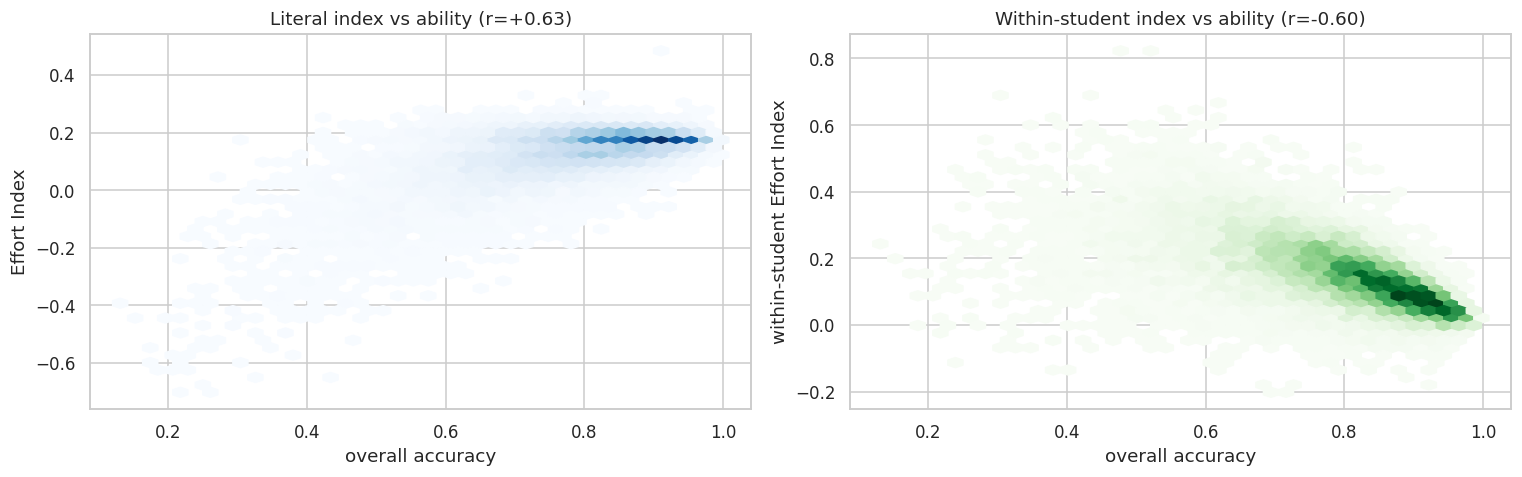

In [9]:
overall_acc = responses.groupby("uid")["responses"].mean().rename("overall_acc")

# ---- within-student KC baseline (LOO) ----
def parse_kc(s):
    try: return [int(k) for k in ast.literal_eval(s)]
    except Exception: return []
q2kc = dict(zip(meta["question_id"], meta["kc_ids"].apply(parse_kc)))

resp_kc = responses.copy(); resp_kc["error"] = 1 - resp_kc["responses"]
resp_kc["kc"] = resp_kc["questions"].map(q2kc)
exploded = resp_kc.explode("kc").dropna(subset=["kc"])
skc = exploded.groupby(["uid", "kc"])["error"].agg(kc_err="mean", kc_n="size")   # per (student, KC)

ez = easy[["uid", "questions", "error"]].copy(); ez["kc"] = ez["questions"].map(q2kc)
ez = ez.explode("kc").dropna(subset=["kc"]).merge(skc, on=["uid", "kc"], how="left")
# leave-one-out: remove this question's own contribution from the student's KC error rate
ez["loo"] = np.where(ez["kc_n"] > 1, (ez["kc_err"]*ez["kc_n"] - ez["error"]) / (ez["kc_n"] - 1), np.nan)
own_base = ez.groupby(["uid", "questions"])["loo"].mean()

easy_r2 = easy.set_index(["uid", "questions"]).copy()
easy_r2["own_base"] = own_base
easy_r2 = easy_r2.dropna(subset=["own_base"])
easy_r2["delta2"] = easy_r2["own_base"] - easy_r2["error"]
effort_R2 = easy_r2.groupby("uid")["delta2"].mean().rename("EffortIndex_withinStudent")

comp = (effort.set_index("uid")[["EffortIndex"]]
        .join(effort_R2).join(overall_acc).dropna(subset=["EffortIndex"]))
c_lit  = comp["EffortIndex"].corr(comp["overall_acc"])
sub    = comp.dropna(subset=["EffortIndex_withinStudent"])
c_r2   = sub["EffortIndex_withinStudent"].corr(sub["overall_acc"])
c_pair = stats.spearmanr(sub["EffortIndex"], sub["EffortIndex_withinStudent"]).correlation
print(f"corr(literal index, ability)         : Pearson {c_lit:+.3f}")
print(f"corr(within-student index, ability)  : Pearson {c_r2:+.3f}")
print(f"corr(literal, within-student)        : Spearman {c_pair:+.3f}")
print(f"within-student index: mean={sub['EffortIndex_withinStudent'].mean():.3f}, "
      f"std={sub['EffortIndex_withinStudent'].std():.3f}, skew={stats.skew(sub['EffortIndex_withinStudent']):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
hb = ax[0].hexbin(comp["overall_acc"], comp["EffortIndex"], gridsize=40, cmap="Blues", mincnt=1)
ax[0].set_title(f"Literal index vs ability (r={c_lit:+.2f})")
ax[0].set_xlabel("overall accuracy"); ax[0].set_ylabel("Effort Index")
ax[1].hexbin(sub["overall_acc"], sub["EffortIndex_withinStudent"], gridsize=40, cmap="Greens", mincnt=1)
ax[1].set_title(f"Within-student index vs ability (r={c_r2:+.2f})")
ax[1].set_xlabel("overall accuracy"); ax[1].set_ylabel("within-student Effort Index")
plt.tight_layout(); plt.show()

**Read-out — baseline choice flips the ability relationship.**
- **Literal index: +0.63** with ability — it partly rewards being good, not just trying.
- **Within-student index: −0.60** — it *over-corrects*: a weak student who gets an easy item right beats
  their own (high) KC baseline by a lot, inflating their score. The two indices are essentially
  **uncorrelated** (Spearman ≈ +0.04).
- **Neither cleanly isolates effort**, and on real data we have **no effort ground-truth** (unlike the
  synthetic mock, which had injected low-effort labels) to declare a winner. So we ship the **literal
  formula** as specified, and treat ability as a known confound — best mitigated by the stricter cut-off
  in §10 and, ultimately, by validating against a true effort signal (e.g. response latency).

## 10 · Sensitivity to the worsening cut-off (and an ability-confound mitigation)

In [10]:
rows = []
for p in [0.25, 0.40, 0.50, 0.60, 0.75, 1.00]:
    tau_p = level1["worsening_rate"].quantile(p)
    ids_p = set(level1.loc[level1["worsening_rate"] <= tau_p, "questions"])
    e_p = responses[responses["questions"].isin(ids_p)].copy()
    e_p["error"] = 1 - e_p["responses"]; e_p["b"] = e_p["questions"].map(base)
    e_p = e_p.dropna(subset=["b"]); e_p["d"] = e_p["b"] - e_p["error"]
    idx = e_p.groupby("uid")["d"].mean()
    rows.append({"quantile_p": p, "tau": tau_p, "n_easy_Q": len(ids_p),
                 "mean": idx.mean(), "std": idx.std(), "skew": stats.skew(idx),
                 "corr_ability": idx.corr(overall_acc.reindex(idx.index))})
display(pd.DataFrame(rows))

,quantile_p,tau,n_easy_Q,mean,std,skew,corr_ability
0,0.2500,0.0285,254,0.1477,0.1107,-3.9147,0.2603
1,0.4000,0.0520,406,0.1298,0.0994,-2.6373,0.5381
2,0.5000,0.0651,507,0.1260,0.0986,-2.5660,0.6299
3,0.6000,0.0833,611,0.1172,0.1004,-2.4402,0.7026
4,0.7500,0.1104,760,0.1119,0.1032,-2.3173,0.7647
5,1.0000,0.5000,1014,0.1066,0.1081,-2.0892,0.8060


**Read-out.** Two useful facts:
- The pipeline is **stable** — mean/SD move smoothly as the pool grows from ~254 to 1014 questions.
- **Stricter is purer.** Tightening the cut-off (p = 0.25, only the *lowest*-worsening questions) drops
  the ability correlation from **+0.63 → +0.26**: missing a question that *truly* almost nobody misses is
  much more about effort than ability. If isolating effort matters more than pool size, use **p ≈ 0.25**;
  the default p = 0.50 is a balance.

## 11 · Export results & final mean / SD

In [11]:
out = (effort.merge(overall_acc, on="uid")
       .merge(effort_R2.reset_index(), on="uid", how="left"))
out["flagged_5pct"]   = out["EffortIndex"] < x.quantile(0.05)
out["flagged_2_5pct"] = out["EffortIndex"] < x.quantile(0.025)
out.to_csv("effort_index_results.csv", index=False)
print("Wrote effort_index_results.csv", out.shape)

print("\n================  FINAL EFFORT-INDEX SUMMARY  ================")
print(f"  students          : {len(x):,}")
print(f"  MEAN              : {x.mean():.4f}")
print(f"  STANDARD DEVIATION: {x.std(ddof=1):.4f}")
print(f"  median            : {x.median():.4f}")
print(f"  recommended flag  : Effort Index < {x.quantile(0.05):.4f}  (5th pct) -> "
      f"{int((x<x.quantile(0.05)).sum()):,} students")
print("=============================================================")
display(out.head())

Wrote effort_index_results.csv (14453, 7)

================  FINAL EFFORT-INDEX SUMMARY  ================
  students          : 14,453
  MEAN              : 0.1260
  STANDARD DEVIATION: 0.0986
  median            : 0.1556
  recommended flag  : Effort Index < -0.0612  (5th pct) -> 723 students


,uid,EffortIndex,n_easy,overall_acc,EffortIndex_withinStudent,flagged_5pct,flagged_2_5pct
0,0,0.1305,18,0.8441,-0.0490,False,False
1,1,0.1973,8,0.7330,0.1917,False,False
2,3,0.2613,17,0.8037,0.2415,False,False
3,4,0.1462,31,0.7605,0.2473,False,False
4,5,0.1813,15,0.9505,0.0133,False,False


## 12 · Conclusions

- **Method (on the real XES3G5M data).** Effort Index = per student, the average over their **easy**
  questions (Level-1 **and** low worsening rate; 507 at the default cut-off) of
  *(KC-baseline error `avg_baseline` − the student's own error)*. **LO = KC**, per the dataset doc.
- **Statistics.** **Mean = 0.126, SD = 0.099**, median 0.156; **strongly left-skewed and non-Gaussian**.
- **Threshold.** Use **percentiles**, not `mean − k·SD`: default **5th percentile** (< −0.061 → ~723
  students); **2.5th** (< −0.143 → ~362) for a high-confidence list.
- **Caveat (surfaced, not hidden).** The literal index correlates **+0.63 with ability**; a within-student
  baseline over-corrects to **−0.60**. With no effort ground-truth in this dataset, neither is provably
  "pure." Mitigate by a **stricter worsening cut-off** (p ≈ 0.25 → confound +0.26) and, for production,
  validate flags against a genuine effort signal such as **response latency** (timestamps exist in
  `processed_responses` and could support a latency-based check in future work).
- **Outputs.** `effort_index_results.csv` — per student: `EffortIndex`, within-student variant,
  `overall_acc`, `n_easy`, and 5%/2.5% flags.